In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import torch
import torch.optim as optim
import numpy as np
from model import NP_model
from dataset import get_image_dataloader, ImageDataset
from train import train
import matplotlib.pyplot as plt

In [37]:
config = {
    'dataset': 'mnist',           # 'mnist' or 'cifar10'
    'max_context_points': 261,  # For MNIST (28x28=784), 392  is 50% of pixels, 261 is 33%
    'batch_size': 32,
    'num_workers': 4,
    'input_dim_x': 2,             # 2D coordinates (x, y)
    'input_dim_y': 1,             # Grayscale (1 for MNIST, 3 for CIFAR10)
    'hidden_dim': 128*3,
    'output_dim': 1,              # Prediction dimension (1 for MNIST, 3 for CIFAR10)
    'learning_rate': 5e-4,
    'num_epochs': 50,
    'save_every': 10,
    'seed': 41,
}


In [38]:

# Set random seed for reproducibility
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create dataloaders
print("Loading datasets...")
train_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    max_context_points=config['max_context_points'],
    train=True,
    flatten=True
)

val_loader = get_image_dataloader(
    dataset_name=config['dataset'],
    batch_size=config['batch_size'],
    num_workers=config['num_workers'],
    max_context_points=config['max_context_points'],
    train=False,
    flatten=True
)

Loading datasets...
Image dimensions (H, W, C): (28, 28, 1)
Using max_context_points: 261
Image dimensions (H, W, C): (28, 28, 1)
Using max_context_points: 261


In [39]:
# Create model
print("\nCreating model...")
model = NP_model(
    input_dim_x=config['input_dim_x'],
    input_dim_y=config['input_dim_y'],
    hidden_dim=config['hidden_dim'],
    output_dim=config['output_dim']
)
model = model.to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params:,} trainable parameters")

# Create optimizer
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])


Creating model...
Model has 452,018 trainable parameters


In [40]:
import time
timestamp = time.strftime("%d_%b_%Y_%H:%M:%S", time.localtime())

model_name = "NP_model_{timestamp}.pt"

# Train
print("\n" + "=" * 60)
train_losses, val_losses = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=config['num_epochs'],
    save_dir='checkpoints',
    save_every=config['save_every'],
    model_name=model_name
)

# Save training history
np.save('checkpoints/train_losses.npy', train_losses)
np.save('checkpoints/val_losses.npy', val_losses)
print("\nTraining history saved to checkpoints/")


Starting training for 50 epochs...
Device: cuda
Training batches: 15000, Validation batches: 2500
------------------------------------------------------------


Epoch   1/50 | Train Loss: -1.586437 | Val Loss: -1.539276
  → Saved best model (val_loss: -1.539276)


Epoch   2/50 | Train Loss: -1.697239 | Val Loss: -1.752601
  → Saved best model (val_loss: -1.752601)


Epoch   3/50 | Train Loss: -1.775245 | Val Loss: -1.799919
  → Saved best model (val_loss: -1.799919)


Epoch   4/50 | Train Loss: -1.833009 | Val Loss: -1.861286
  → Saved best model (val_loss: -1.861286)


...

Epoch  46/50 | Train Loss: -2.059788 | Val Loss: -2.078262


Epoch  47/50 | Train Loss: -2.061715 | Val Loss: -2.076822


Epoch  48/50 | Train Loss: -2.059705 | Val Loss: -2.067698


Epoch  49/50 | Train Loss: -2.065347 | Val Loss: -2.059301


Epoch  50/50 | Train Loss: -2.065686 | Val Loss: -2.077554
------------------------------------------------------------
Training complete! Best validation loss: -2.080468

Training history saved to checkpoints/


In [53]:
!ls checkpoints/

best_model.pt		 checkpoint_epoch_40.pt
checkpoint_epoch_100.pt  checkpoint_epoch_50.pt
checkpoint_epoch_10.pt	 checkpoint_epoch_60.pt
checkpoint_epoch_110.pt  checkpoint_epoch_70.pt
checkpoint_epoch_120.pt  checkpoint_epoch_80.pt
checkpoint_epoch_130.pt  checkpoint_epoch_90.pt
checkpoint_epoch_140.pt  NP_model_28_Apr_2026_15:04:53.pt
checkpoint_epoch_20.pt	 train_losses.npy
checkpoint_epoch_30.pt	 val_losses.npy


In [54]:
from utils import load_model_from_checkpoint
best_model, checkpoint_info = load_model_from_checkpoint('checkpoints/NP_model_28_Apr_2026_15:04:53.pt', config['input_dim_x'], config['input_dim_y'], config['hidden_dim'], config['output_dim'], device='cuda')

Loaded model from checkpoints/NP_model_28_Apr_2026_15:04:53.pt
  Epoch: 49
  Train Loss: -2.086493
  Val Loss: -2.102866


/work/ka1176/paul/neural_process_demo/utils.py:375: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


In [46]:
att = torch.nn.MultiheadAttention(embed_dim=5, num_heads=1, batch_first=True)

In [51]:
attention, weights = att(torch.ones(2,10,5),torch.ones(2,10,5),torch.ones(2,10,5))

In [52]:
attention

tensor([[[-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024]],

        [[-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056,  0.8024],
         [-0.0275,  0.6708, -0.3667, -0.4056, 

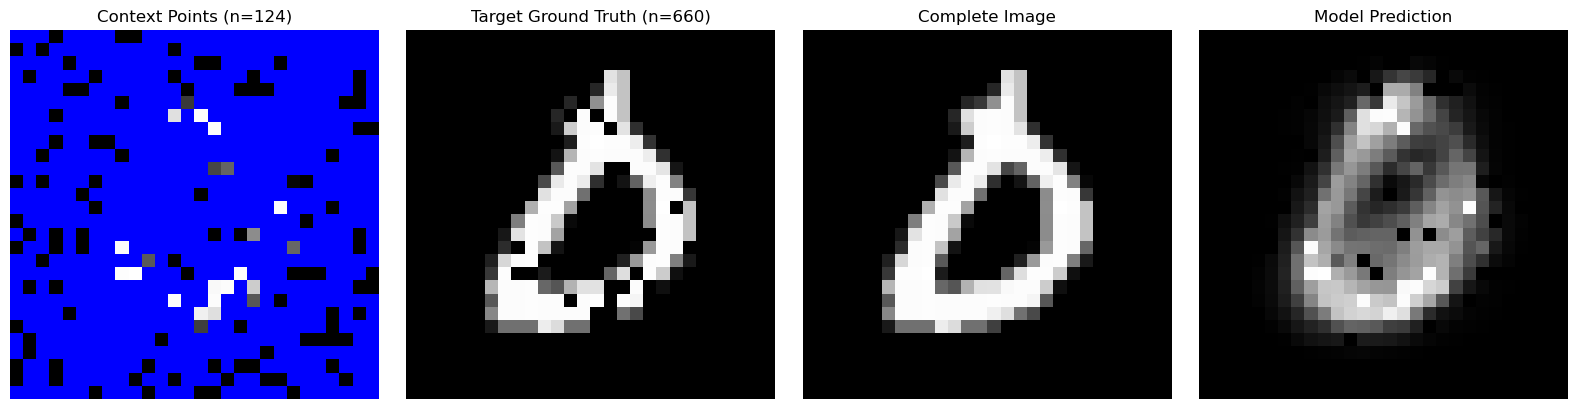

In [71]:
from utils import plot_mnist_sample, plot_prediction_comparison, plot_training_curves
from dataset import get_image_dataloader

# Get a batch
batch = next(iter(train_loader))


# With model predictions
fig = plot_mnist_sample(batch, batch_idx=1, model=best_model, device='cuda')
plt.show()



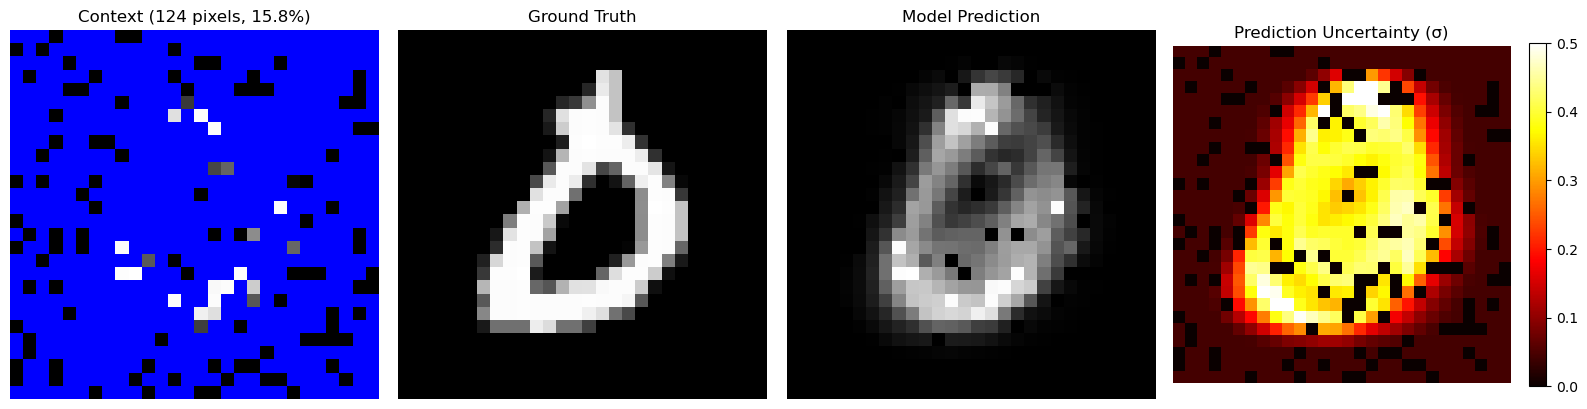

In [72]:
# Detailed comparison with uncertainty
fig = plot_prediction_comparison(batch, batch_idx=1, model=best_model, device='cuda')
plt.show()